# Main Analysis

In [118]:
import numpy as np
import pandas as pd
from scipy.stats import chi2
from sklearn.neighbors import NearestNeighbors
import scanpy as sc
import scanpy.external as sce
import os

In [ ]:
import sys
import os

# Get the path to the directory containing 'scripts/' 
# (assuming your notebook is in the project root or a sibling folder)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
scripts_path = os.path.join(project_root, "scripts")

if scripts_path not in sys.path:
    sys.path.insert(0, scripts_path)

In [119]:
sc.set_figure_params(figsize=(6, 6), frameon=False)


In [120]:
rev_n = 12 # Use 12
region = 'cerebral_cortex' # Options: 'cerebral_cortex', 'hippocampus'
path_to_data = f"/home/ratopin/big_data/nmr/{region}_nmr_adata_filtered{rev_n}.h5ad"

In [121]:
### PARAMETERS
batch_key = "sample"
resolution = 1.5
sub_res = 5.0
n_hvg = 6000


In [122]:
adata = sc.read_h5ad(path_to_data)
adata.obs_names_make_unique()
print(adata)

AnnData object with n_obs × n_vars = 24378 × 17413
    obs: 'species', 'sample', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'total_counts_tf', 'log1p_total_counts_tf', 'pct_counts_tf', 'n_counts', 'qc_composite', 'qc_label', 'sample_id', 'replicate'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'


In [123]:
#Using rule of thumb  for n_neigbors used on neighors
import math
n_cells = adata.shape[0]
n_neighb = int(math.log10(n_cells) * 10)
print(f"Recommended n_neighbors ~ {n_neighb}")

Recommended n_neighbors ~ 43


## Quality control
QC was already performed in `main_preprocessing.ipynb`

/tmp/ipykernel_3154111/3563787129.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", save=f"_{region}_qc.png")


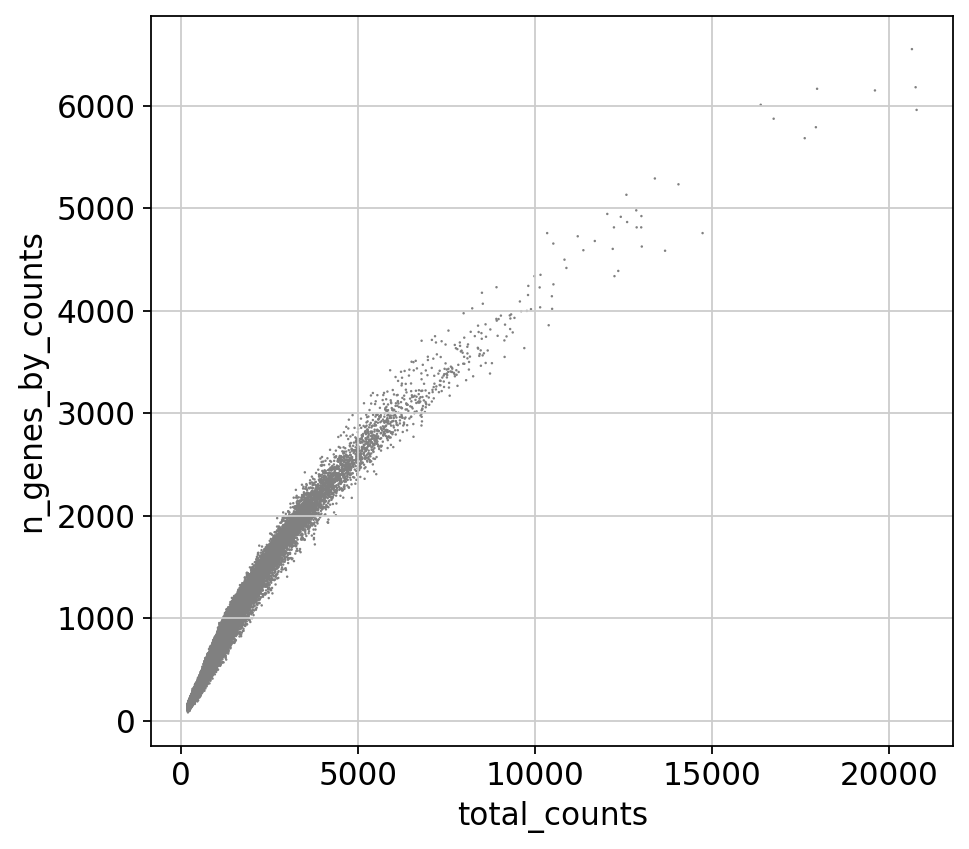

In [124]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", save=f"_{region}_qc.png")

In [126]:
#sc.pp.scrublet(adata, batch_key=batch_key)

/tmp/ipykernel_3154111/1929927355.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.scrublet_score_distribution(adata, save=f"_{region}.png")


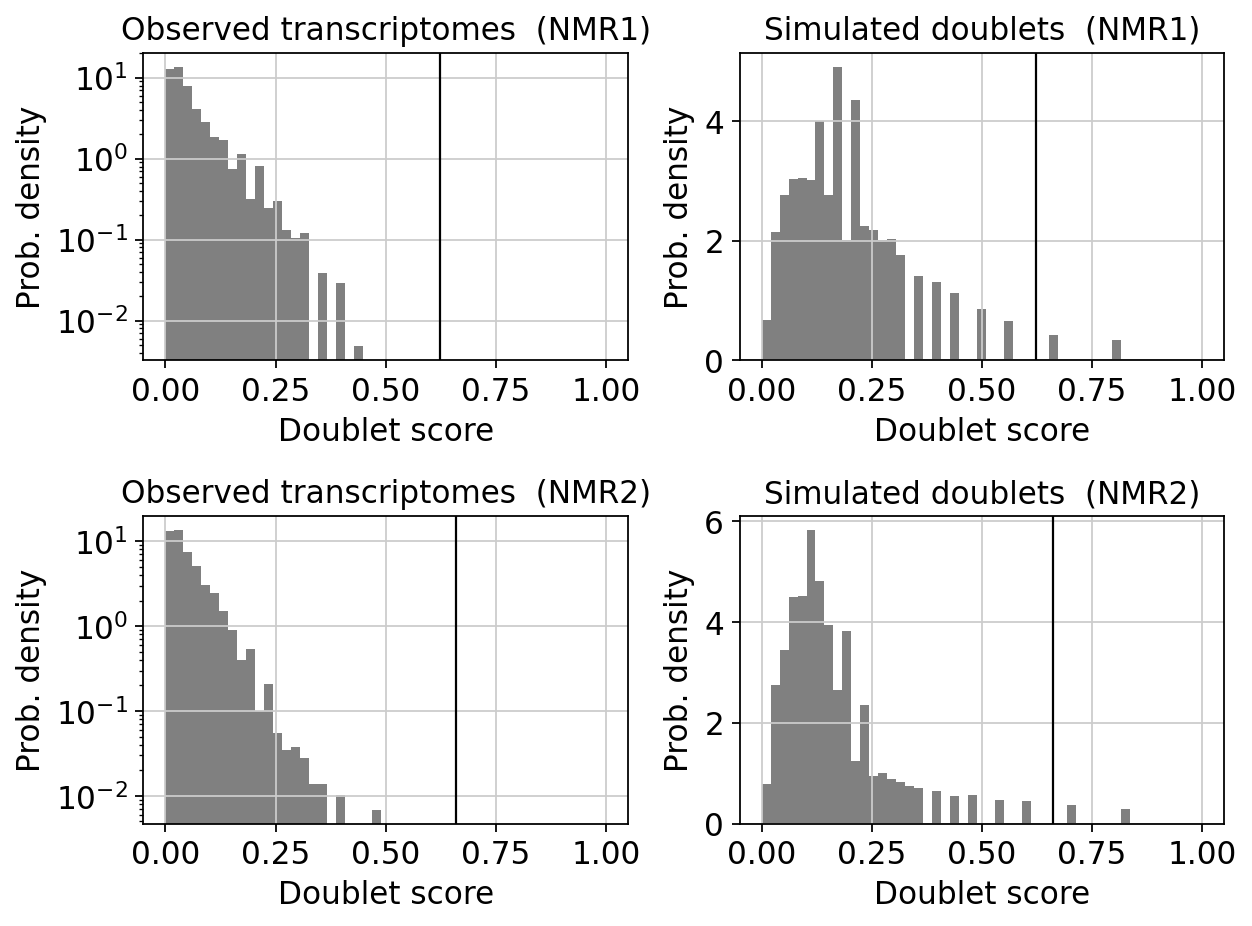

In [ ]:
sc.pl.scrublet_score_distribution(adata, save=f"_{region}.png")

In [ ]:
adata.obs["predicted_doublet"].value_counts()

predicted_doublet
False    24378
Name: count, dtype: int64

In [127]:
sc.pp.highly_variable_genes(
    adata, 
    n_top_genes=n_hvg, 
    subset=False, 
    flavor="seurat_v3", 
    batch_key=batch_key
)

# Store raw counts in a layer for later use in DE analysis
adata.layers["counts"] = adata.X.copy()

# Standard normalization and log transformation
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.scale(adata, max_value=10)
sc.pp.pca(adata, svd_solver='arpack')


/home/ratopin/miniconda3/envs/scanpy-env/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Axes: Axes(0.11744,0.15;0.588373x0.76)


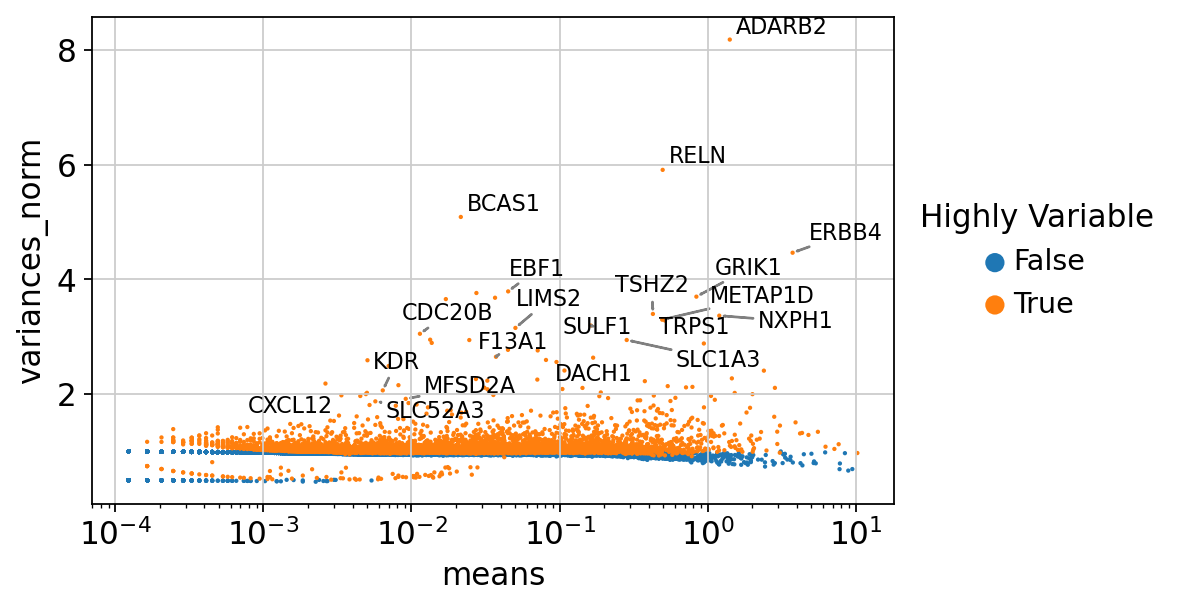

In [ ]:
# Package used for adding well aligned labels on the plot
from adjustText import adjust_text
import matplotlib.pyplot as plt

tophvg = adata.var.sort_values('highly_variable_rank').head(20).index.to_list()
with plt.rc_context({"figure.figsize": (6,4)}):
    x = "means"
    y = "variances_norm"
    color = "is_highly_variable"

    adata.var["is_highly_variable"] = (
        adata.var["highly_variable"]
        .astype(bool)
        .astype(str)
    )

    ax = sc.pl.scatter(
        adata,
        x=x,
        y=y,
        color=color,
        show=False,
        size=15
    )

    # Log-transform x axis
    ax.set_xscale("log")

    print("Axes:", ax)

    # Move plot title from Axes to Legend
    ax.set_title("")
    ax.get_legend().set_title("Highly Variable")

    # Labels
    texts = []
    genes = tophvg

    for gene in genes:
        x_loc = adata.var.loc[gene, x]
        y_loc = adata.var.loc[gene, y]

        texts.append(
            ax.text(
                x_loc,
                y_loc,
                gene,
                color="k",
                fontsize=10
            )
        )

    _ = adjust_text(
        texts,
        expand=(1.2, 1.2),
        arrowprops=dict(color="gray", lw=1),
        ax=ax,
    )
      # Save figure
    plt.savefig(
        f"scatter_{region}_hvg.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

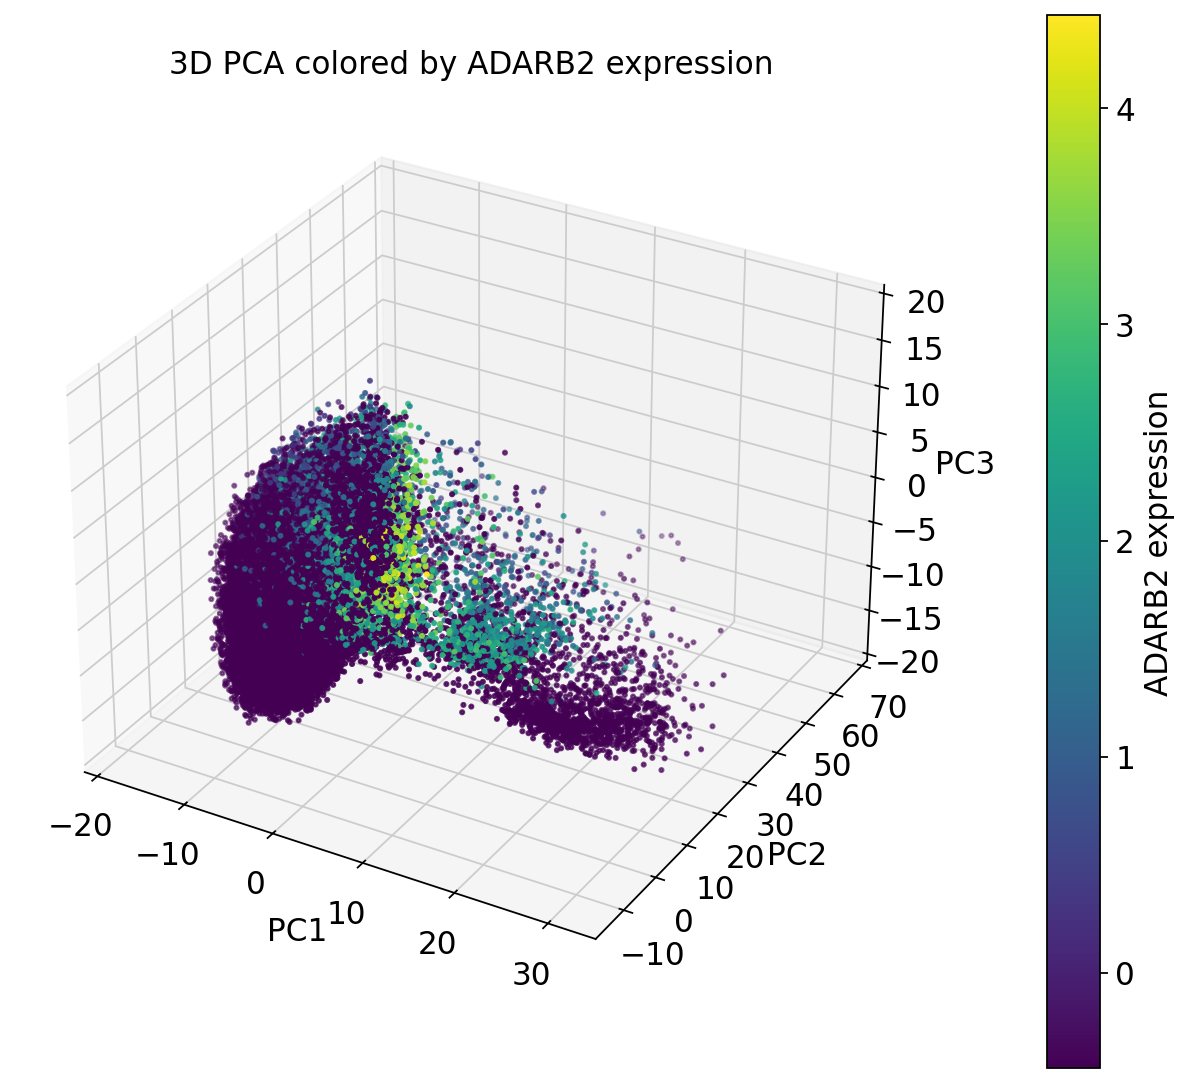

In [130]:
# Run PCA
sc.tl.pca(adata, svd_solver='arpack')

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Extract first 3 PCs
pcs = adata.obsm["X_pca"][:, :3]

# Gene to color by
gene = "ADARB2"

# Extract expression values
if gene in adata.var_names:
    expr = adata[:, gene].X

    # Convert sparse matrix if needed
    if hasattr(expr, "toarray"):
        expr = expr.toarray()

    expr = np.ravel(expr)
else:
    raise ValueError(f"{gene} not found in adata.var_names")

# Create figure
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pcs[:, 0],
    pcs[:, 1],
    pcs[:, 2],
    c=expr,
    s=3
)

# Axis labels
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

ax.set_title(f"3D PCA colored by {gene} expression")

# Colorbar
cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label(f"{gene} expression")

plt.tight_layout()

# Save figure
plt.savefig(
    f"{region}_PCA_3D_ADARB2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

/tmp/ipykernel_3154111/1680573387.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(adata, save=f"_{region}_pca.png", annotate_var_explained=True, )


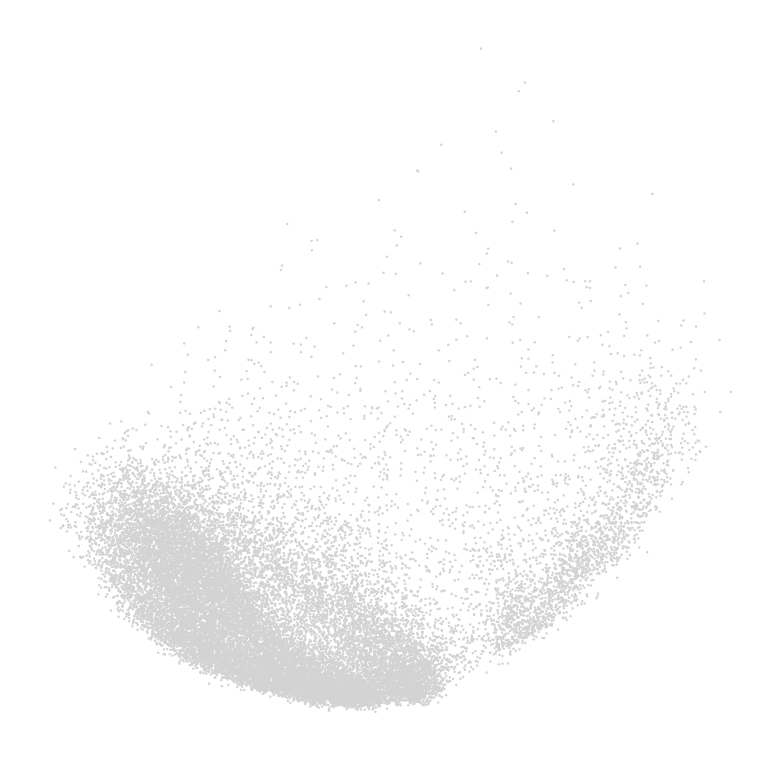

In [131]:
sc.pl.pca(adata, save=f"_{region}_pca.png", annotate_var_explained=True, )

/tmp/ipykernel_3154111/1988797013.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca_variance_ratio(adata, log=True, save=f"_{region}_pca_variance.png")


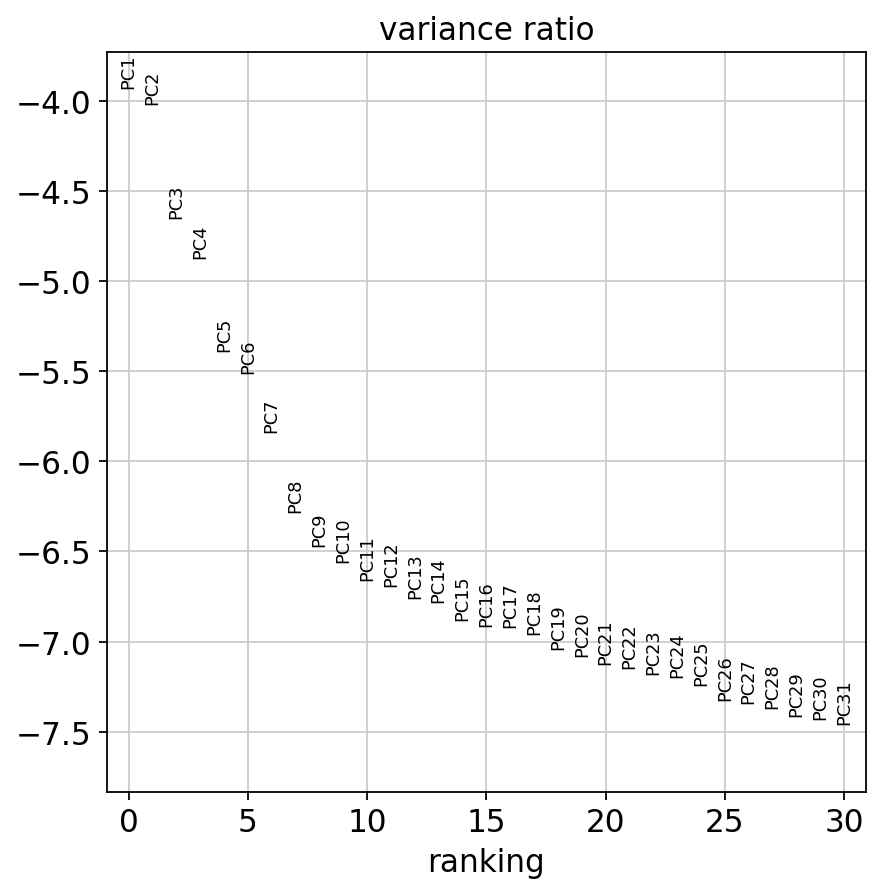

In [138]:
sc.pl.pca_variance_ratio(adata, log=True, save=f"_{region}_pca_variance.png")

In [132]:
sc.pp.neighbors(adata, n_neighbors= n_neighb)


In [133]:
sc.tl.umap(adata)


In [134]:
sc.tl.leiden(adata, key_added=f'leiden_{resolution}', resolution=resolution)


/tmp/ipykernel_3154111/642379986.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, key_added=f'leiden_{resolution}', resolution=resolution)


In [135]:
sc.tl.leiden(adata, key_added=f'leiden_{sub_res}', resolution=sub_res)


/tmp/ipykernel_3154111/2725006417.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, key_added=f'leiden_{sub_res}', resolution=sub_res)


/tmp/ipykernel_3154111/2153629836.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(adata, color=[batch_key, f'leiden_{resolution}', f'leiden_{sub_res}'], wspace=0.3, save=f"_{region}_leiden.png")


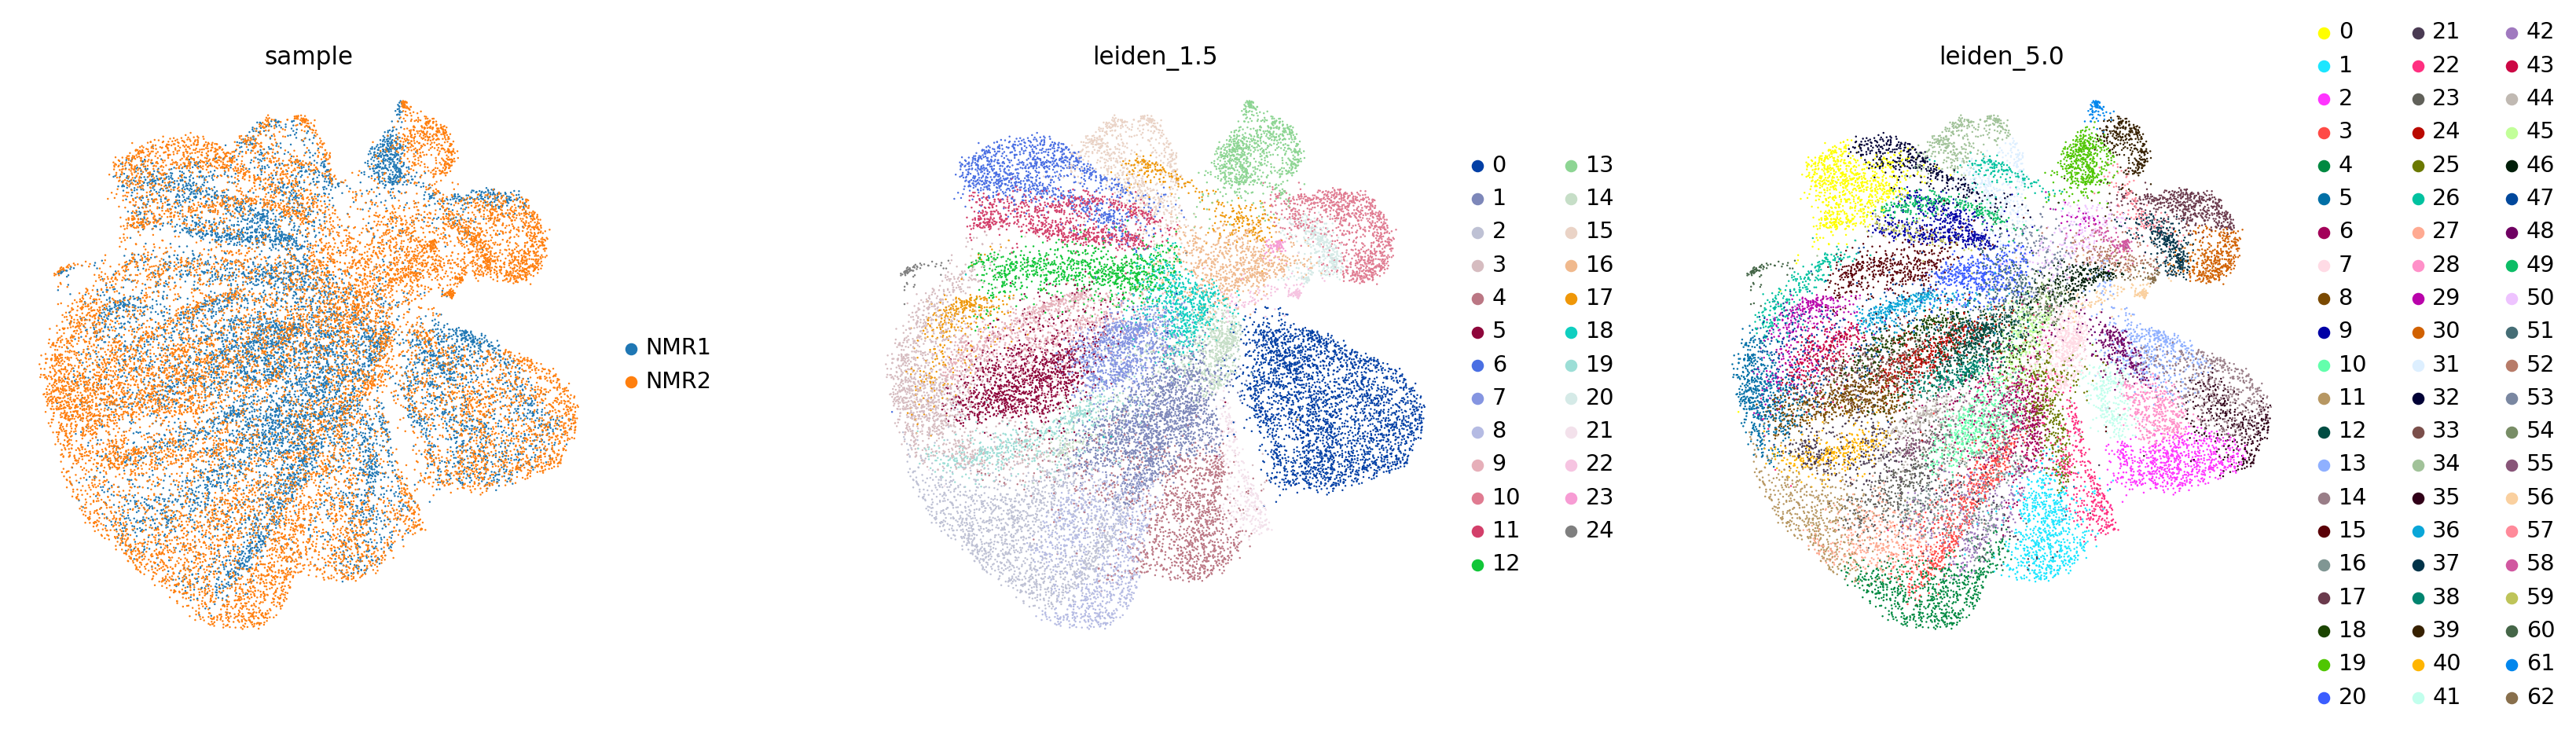

In [136]:
sc.pl.umap(adata, color=[batch_key, f'leiden_{resolution}', f'leiden_{sub_res}'], wspace=0.3, save=f"_{region}_leiden.png")

In [137]:
adata.var['highly_variable'].sum()

np.int64(6000)

In [105]:
# Save the processed data
output_path = f"/home/ratopin/big_data/nmr/{region}_nmr_adata_processed{rev_n}.h5ad"
adata.write_h5ad(output_path)
print(f"Processed data saved to {output_path}")

Processed data saved to /home/ratopin/big_data/nmr/hippocampus_nmr_adata_processed12.h5ad
